## Data Preparation


In [1]:
import pandas as pd

df = pd.read_csv("adult-dataset.csv")
df.head()

,age,workClass,Education,marital-status,occupation,race,sex,hours-per-week,Income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,White,Male,40,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,White,Male,13,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,White,Male,40,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Black,Male,40,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Black,Female,40,<=50K


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workClass       32561 non-null  str  
 2   Education       32561 non-null  str  
 3   marital-status  32561 non-null  str  
 4   occupation      32561 non-null  str  
 5   race            32561 non-null  str  
 6   sex             32561 non-null  str  
 7   hours-per-week  32561 non-null  int64
 8   Income          32561 non-null  str  
dtypes: int64(2), str(7)
memory usage: 2.2 MB


In [3]:
# Check for missing values
df.dropna(inplace=True)
df.isnull().any(axis=0).sum()

np.int64(0)

In [4]:
import numpy as np

y = df["Income"].str.strip().replace({"<=50K": 0, ">50K": 1}).astype(int)
X = df.drop("Income", axis=1)

In [5]:
for column in X.columns:
    if X[column].dtype == "str":
        # Remove extra whitespaces and replace values
        X[column] = X[column].str.strip()

        # Apply one-hot encoding
        encoder = pd.get_dummies(X[column], prefix=column.lower())

        # Integrate the encoded columns back into the original DataFrame
        X = pd.concat([X, encoder], axis=1)

        # Drop the original categorical column
        X.drop(column, axis=1, inplace=True)

## Exploratory Data Analysis (EDA)


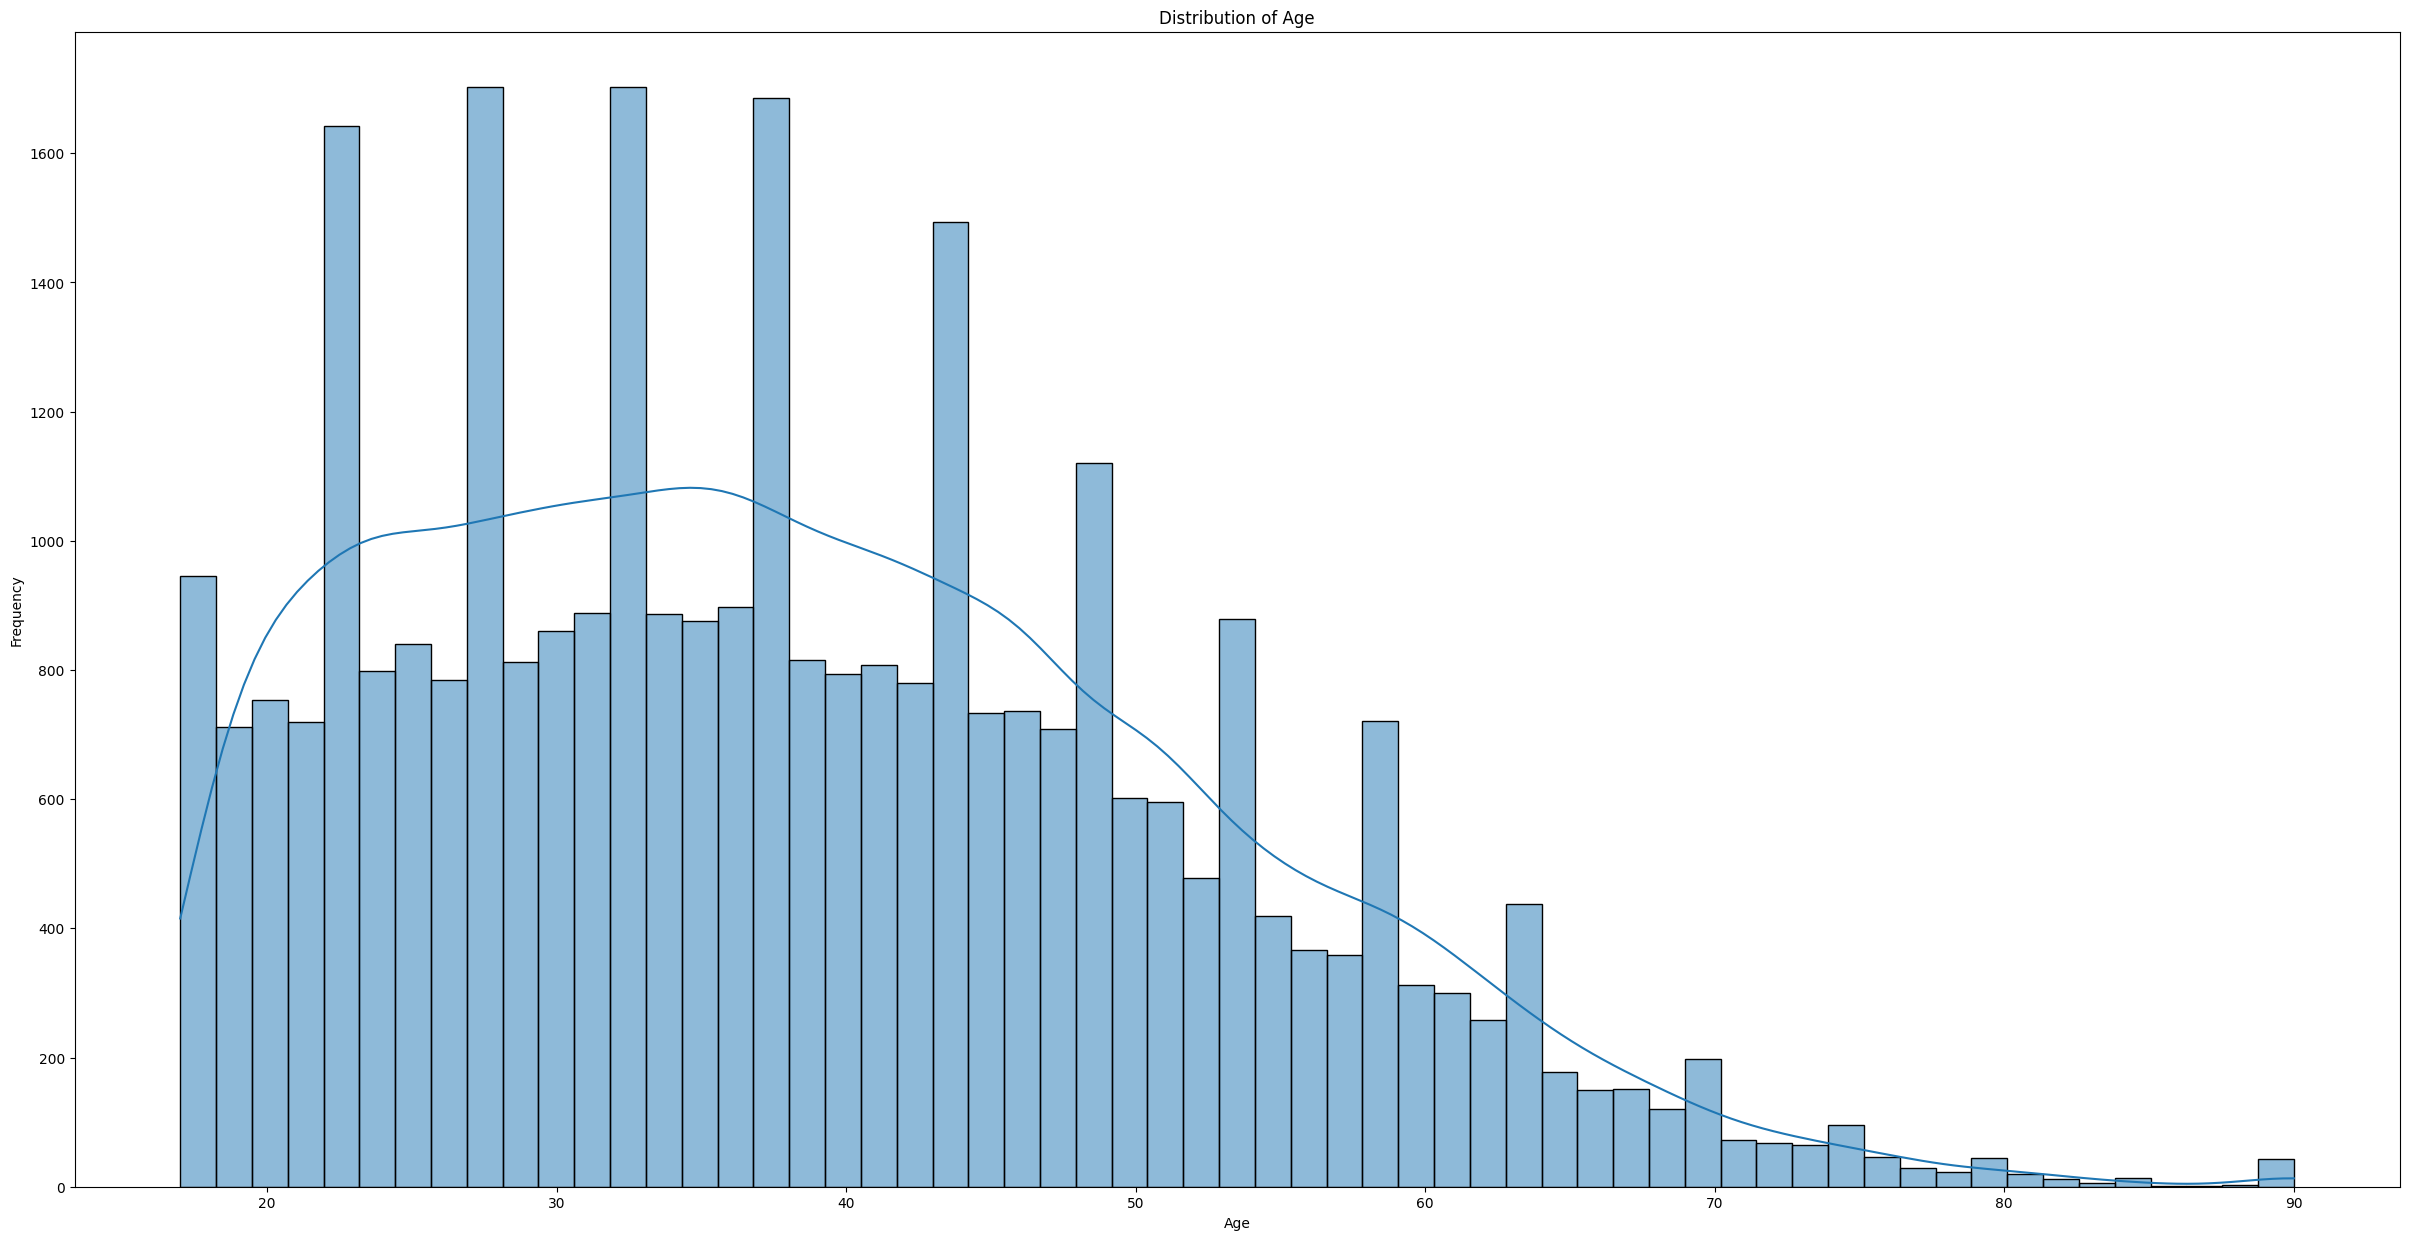

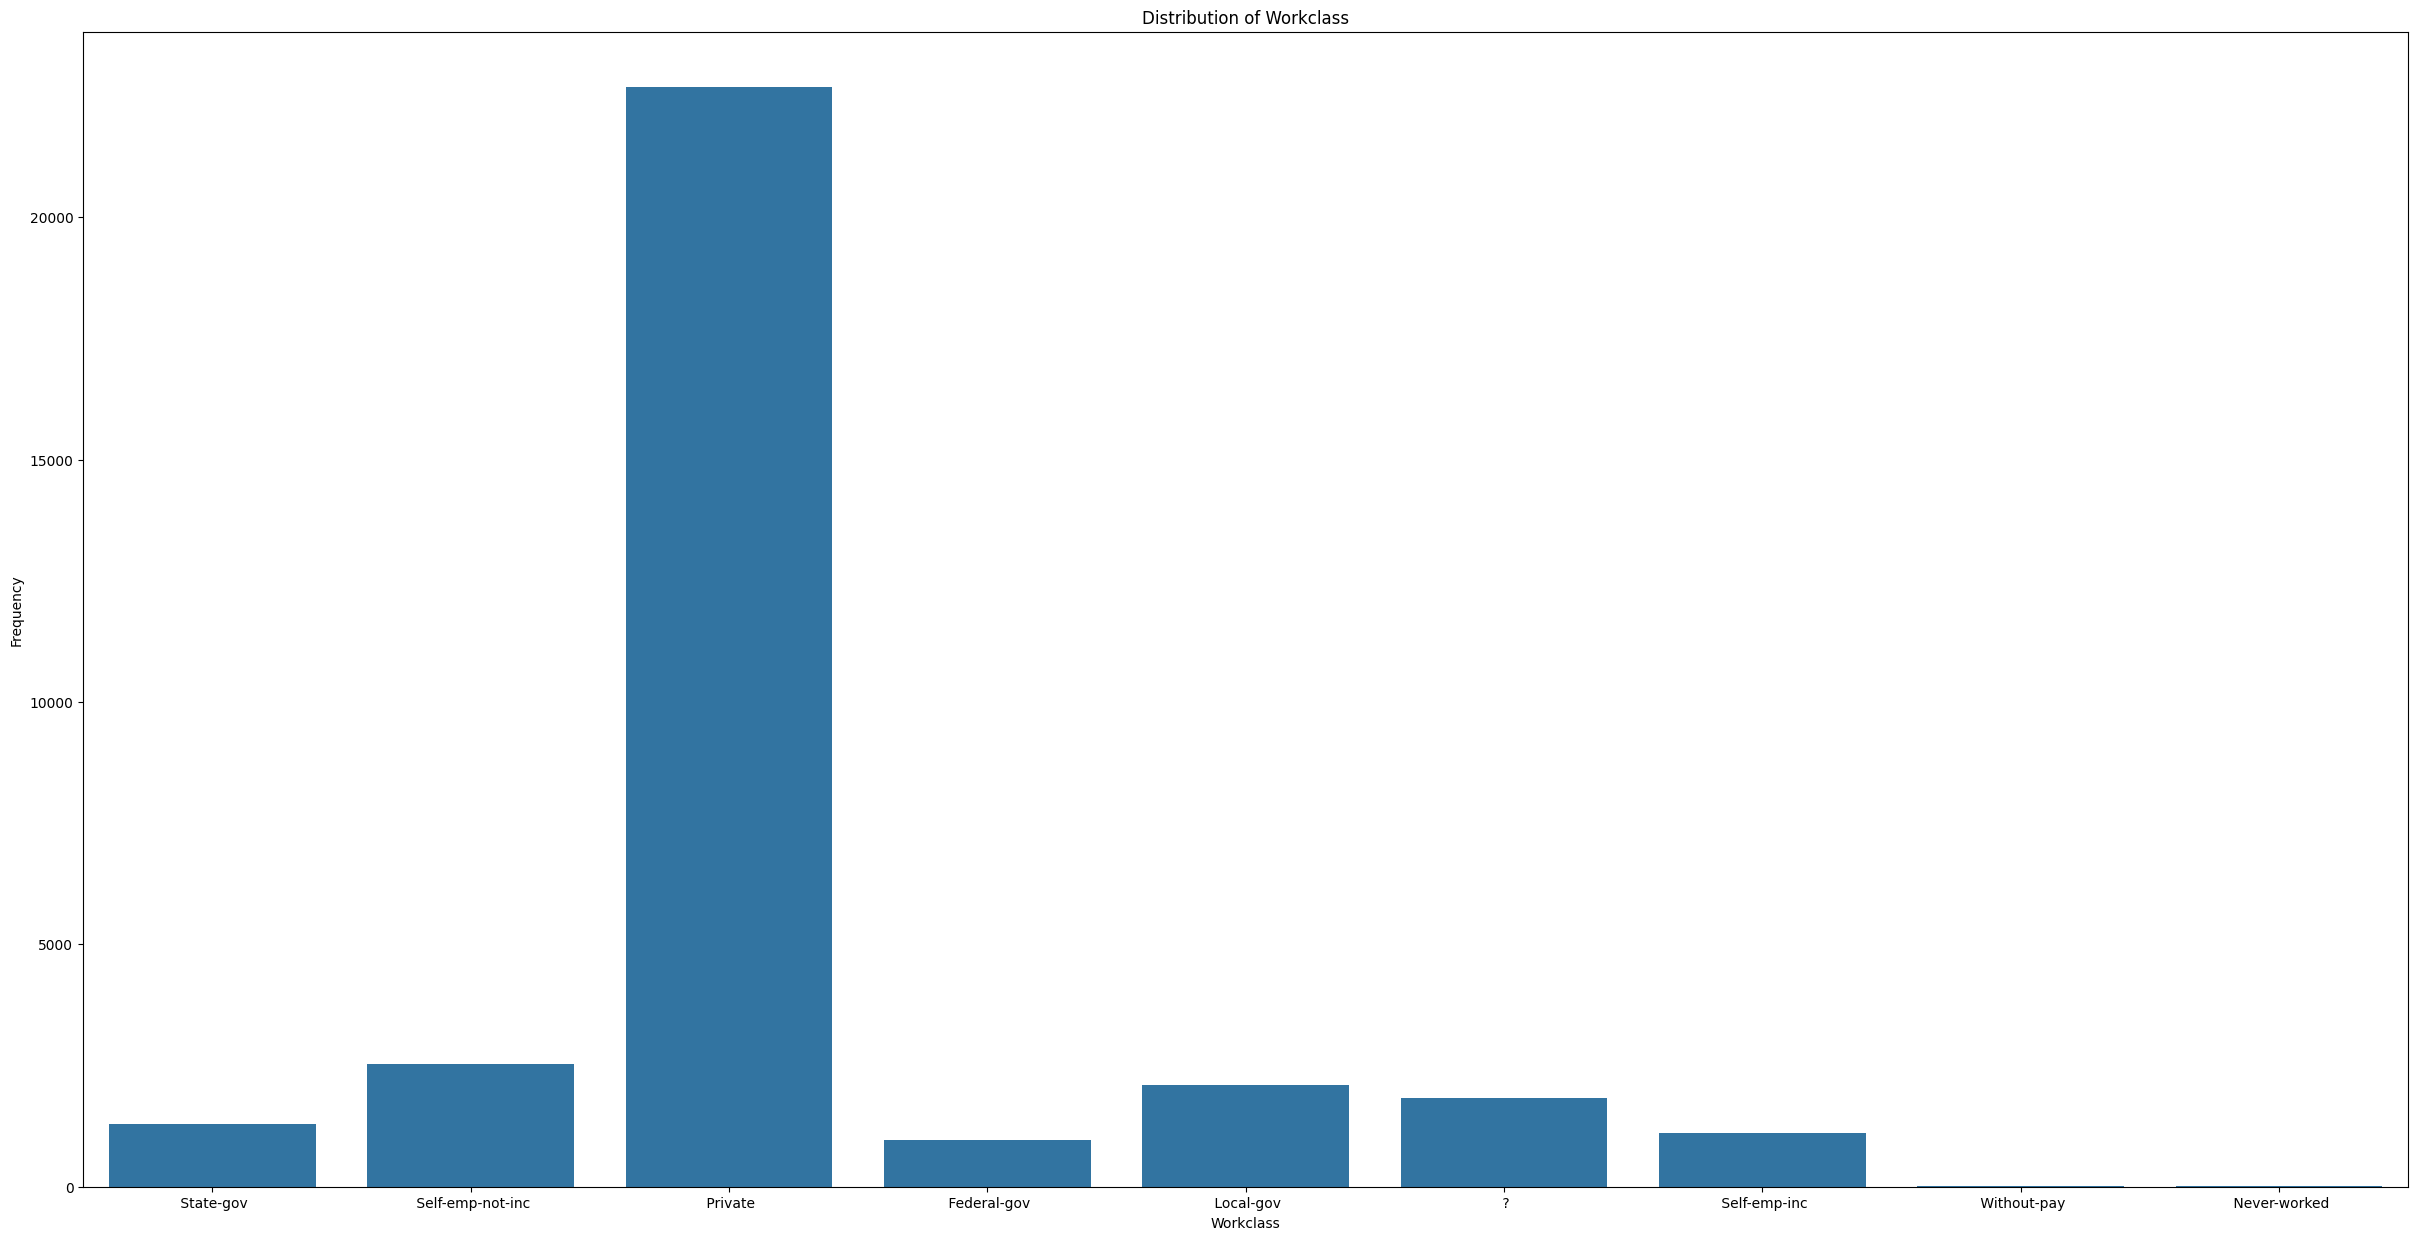

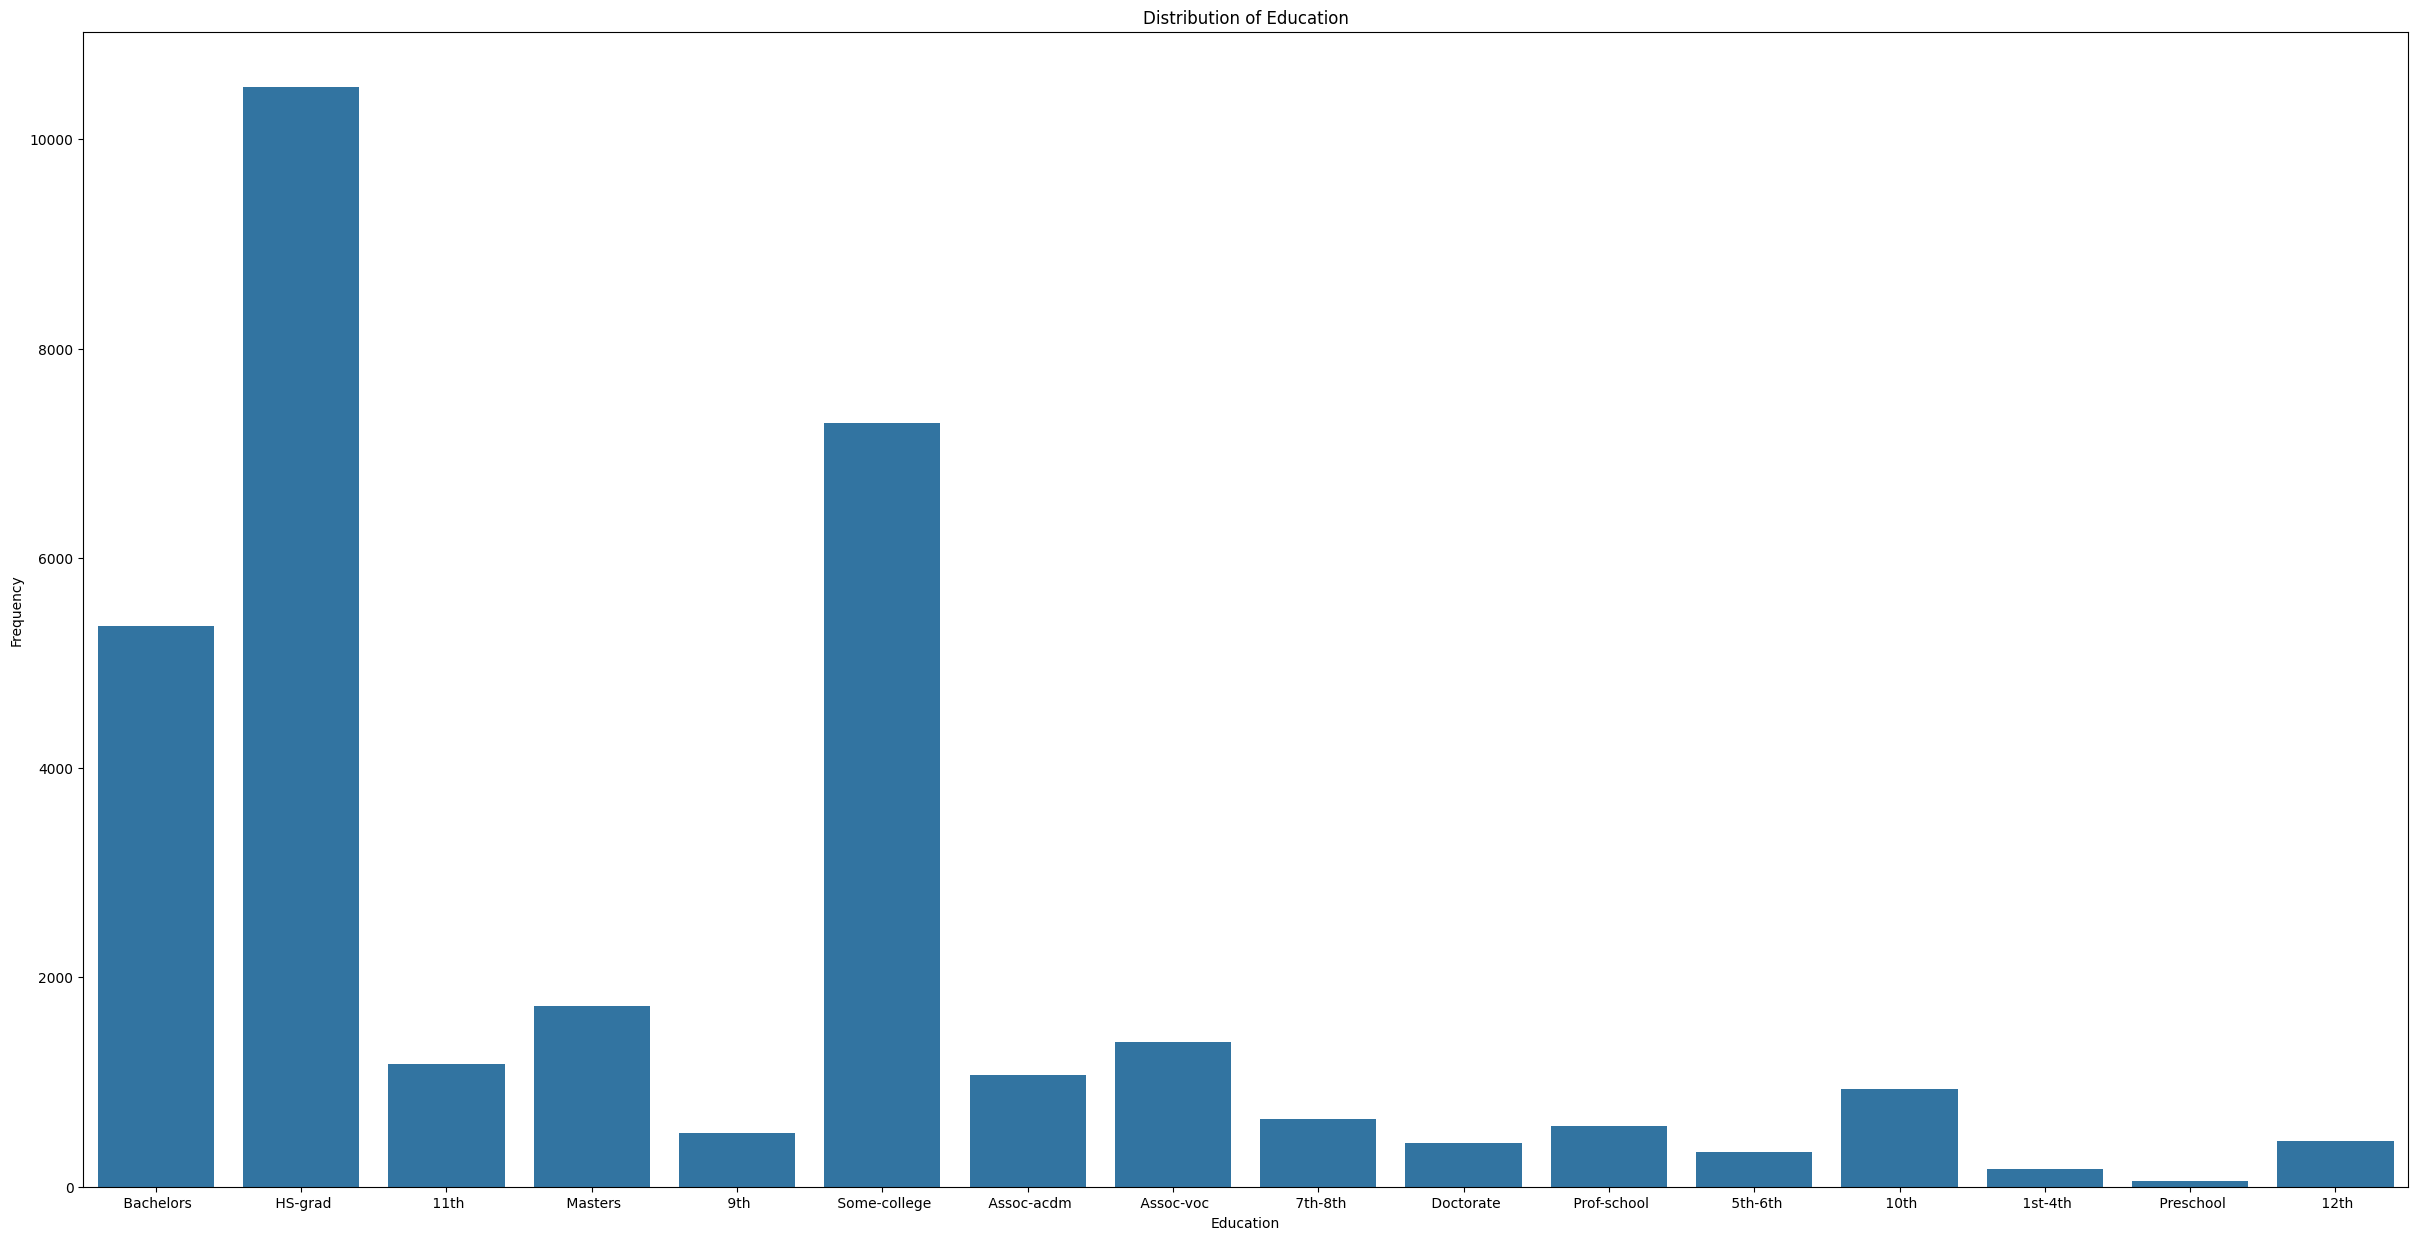

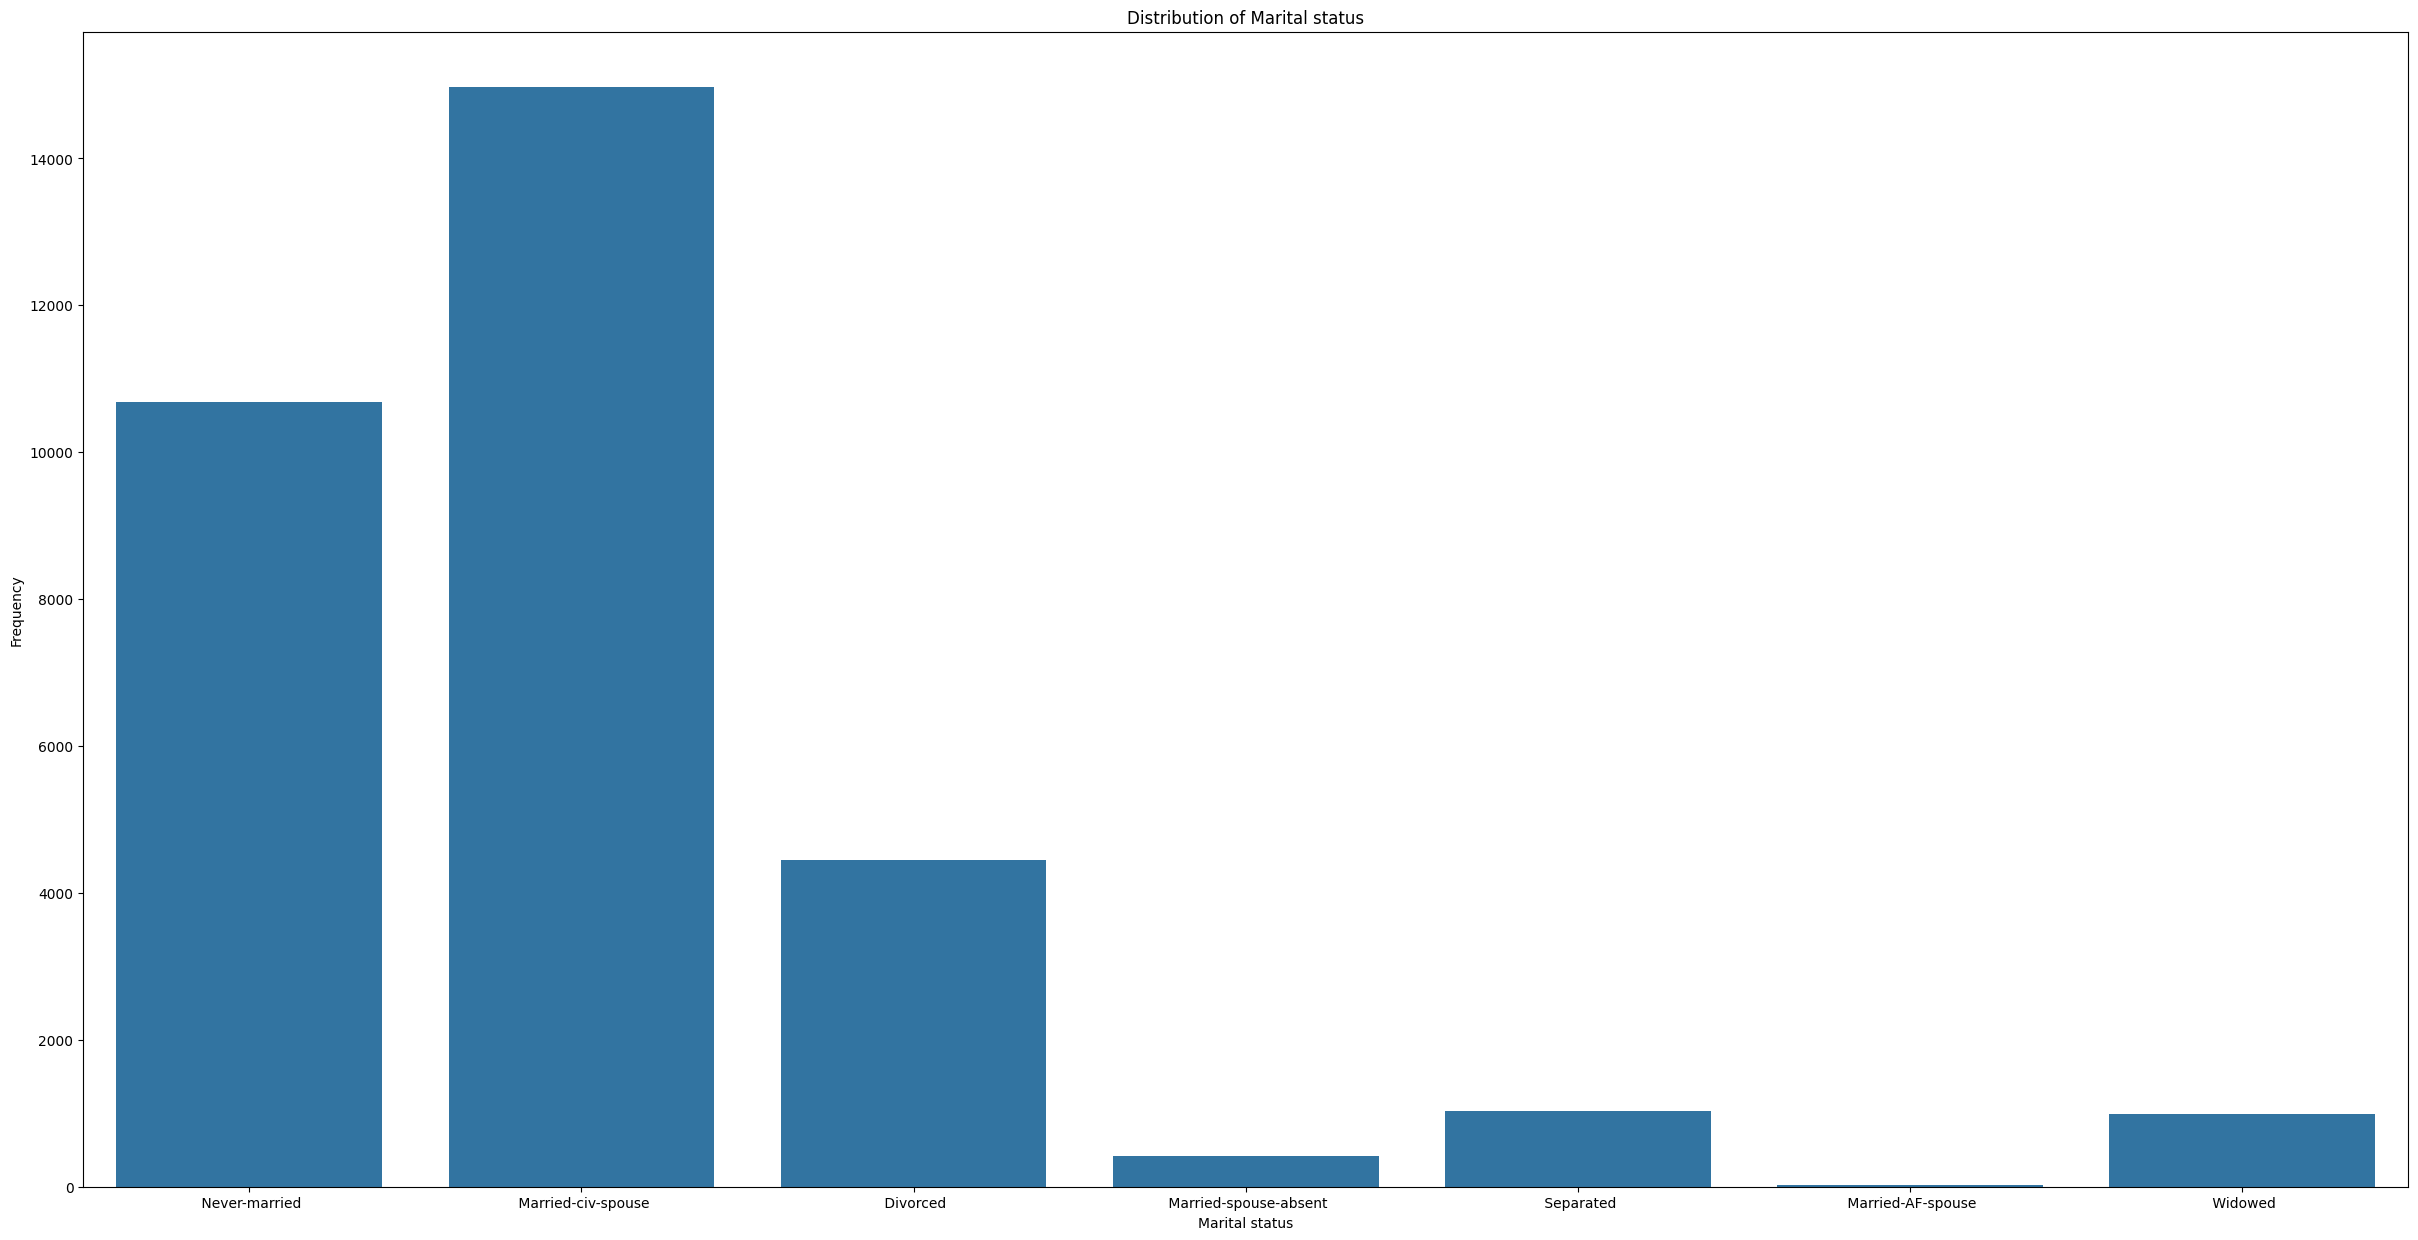

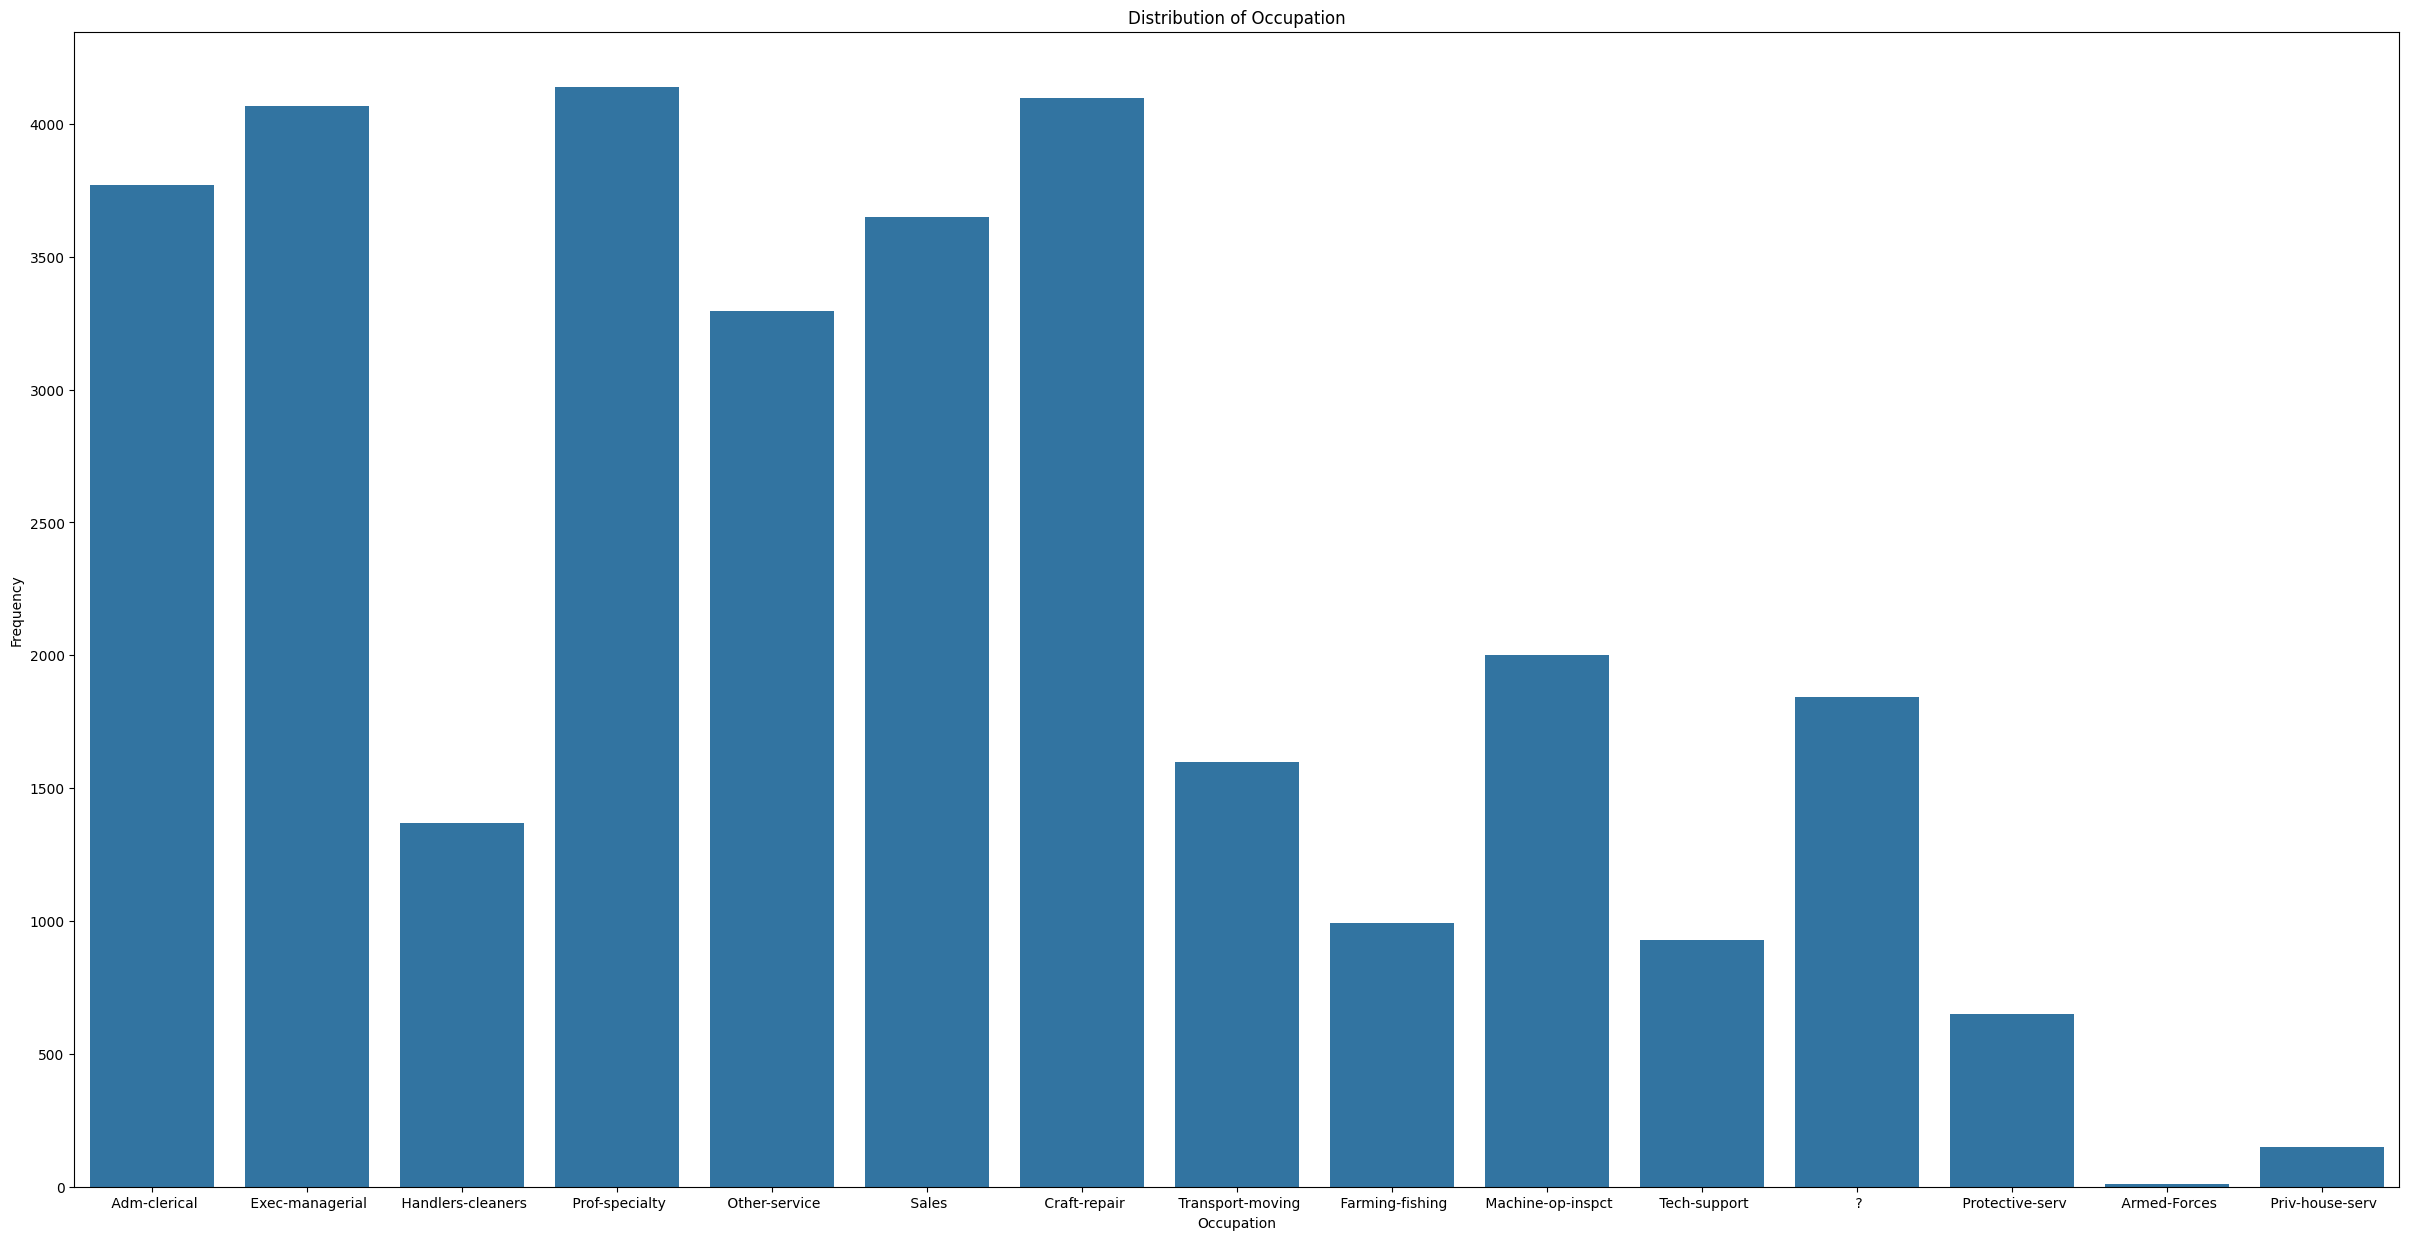

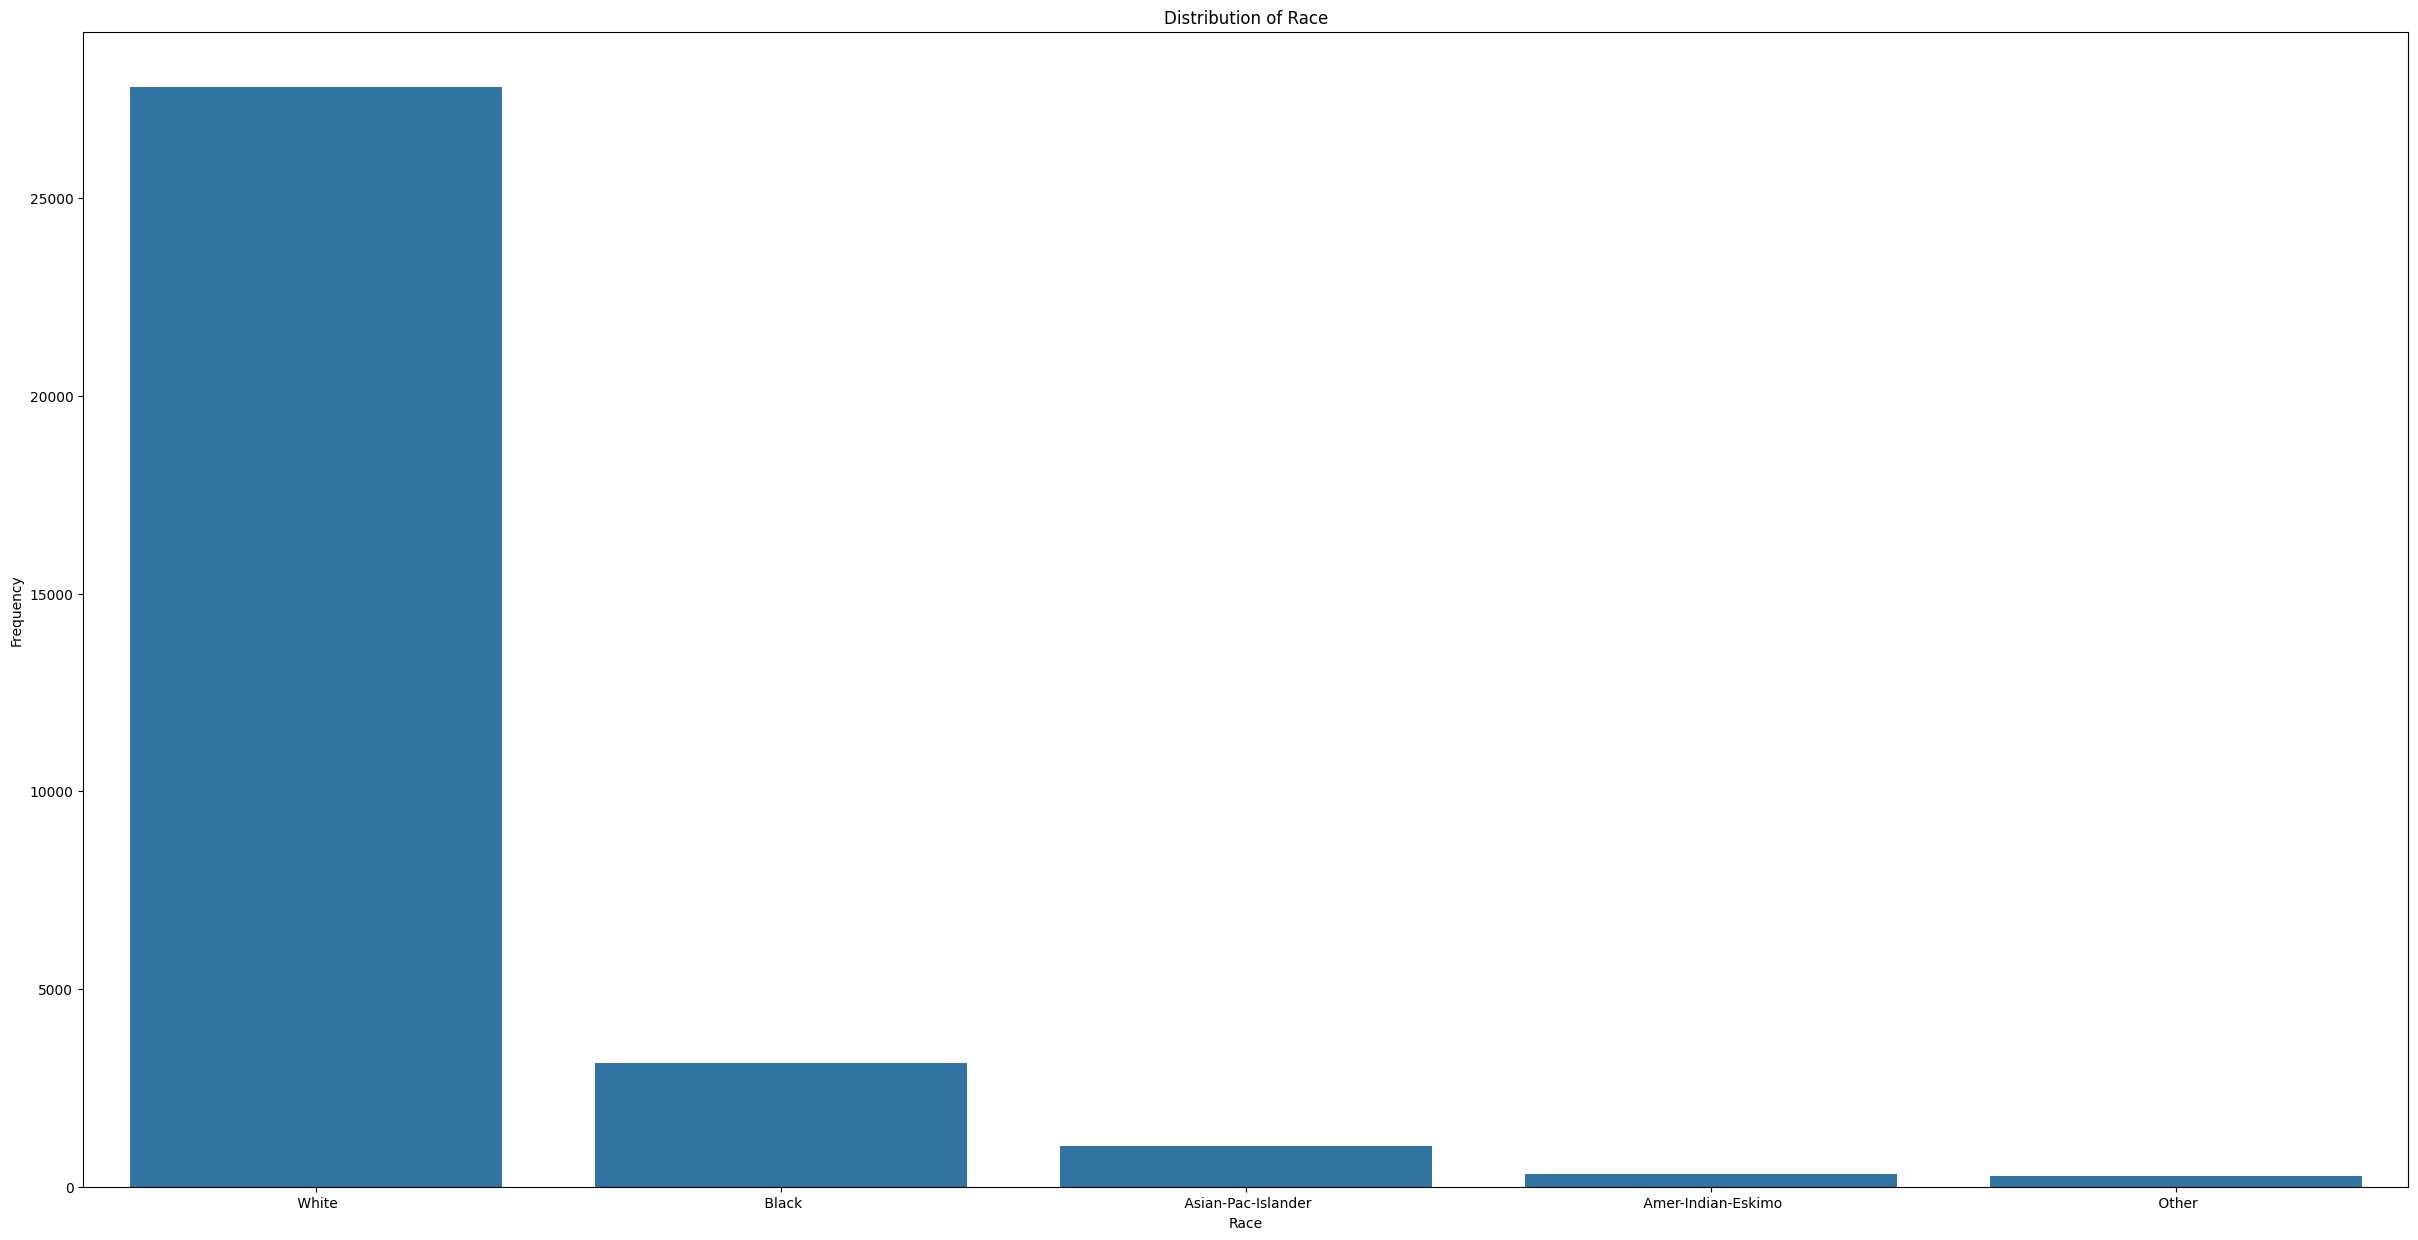

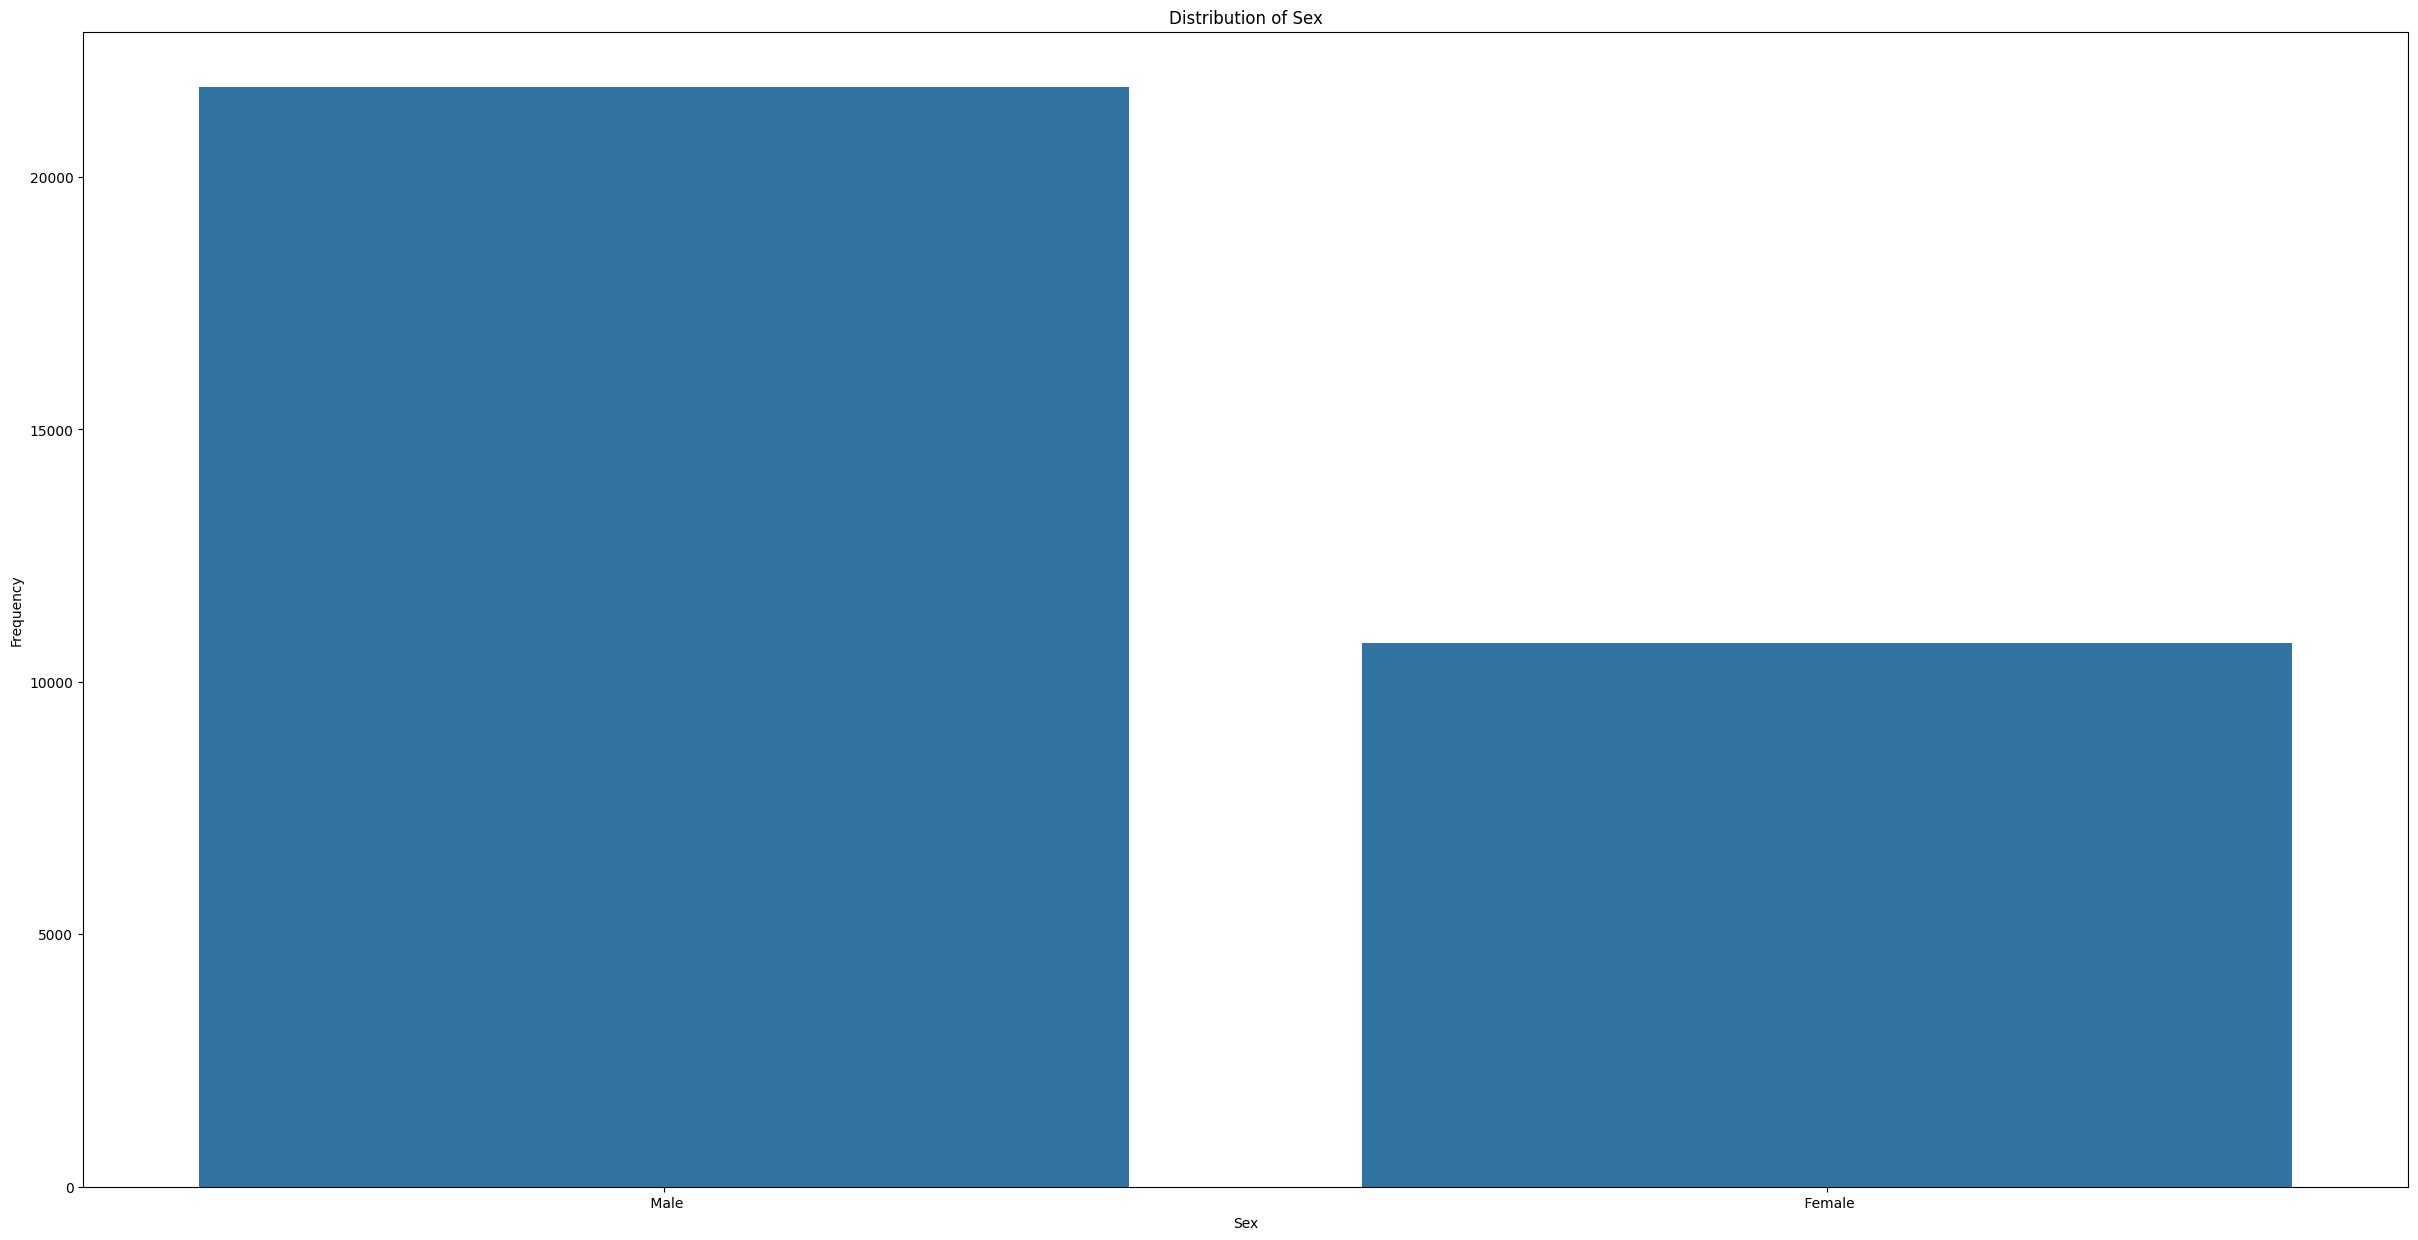

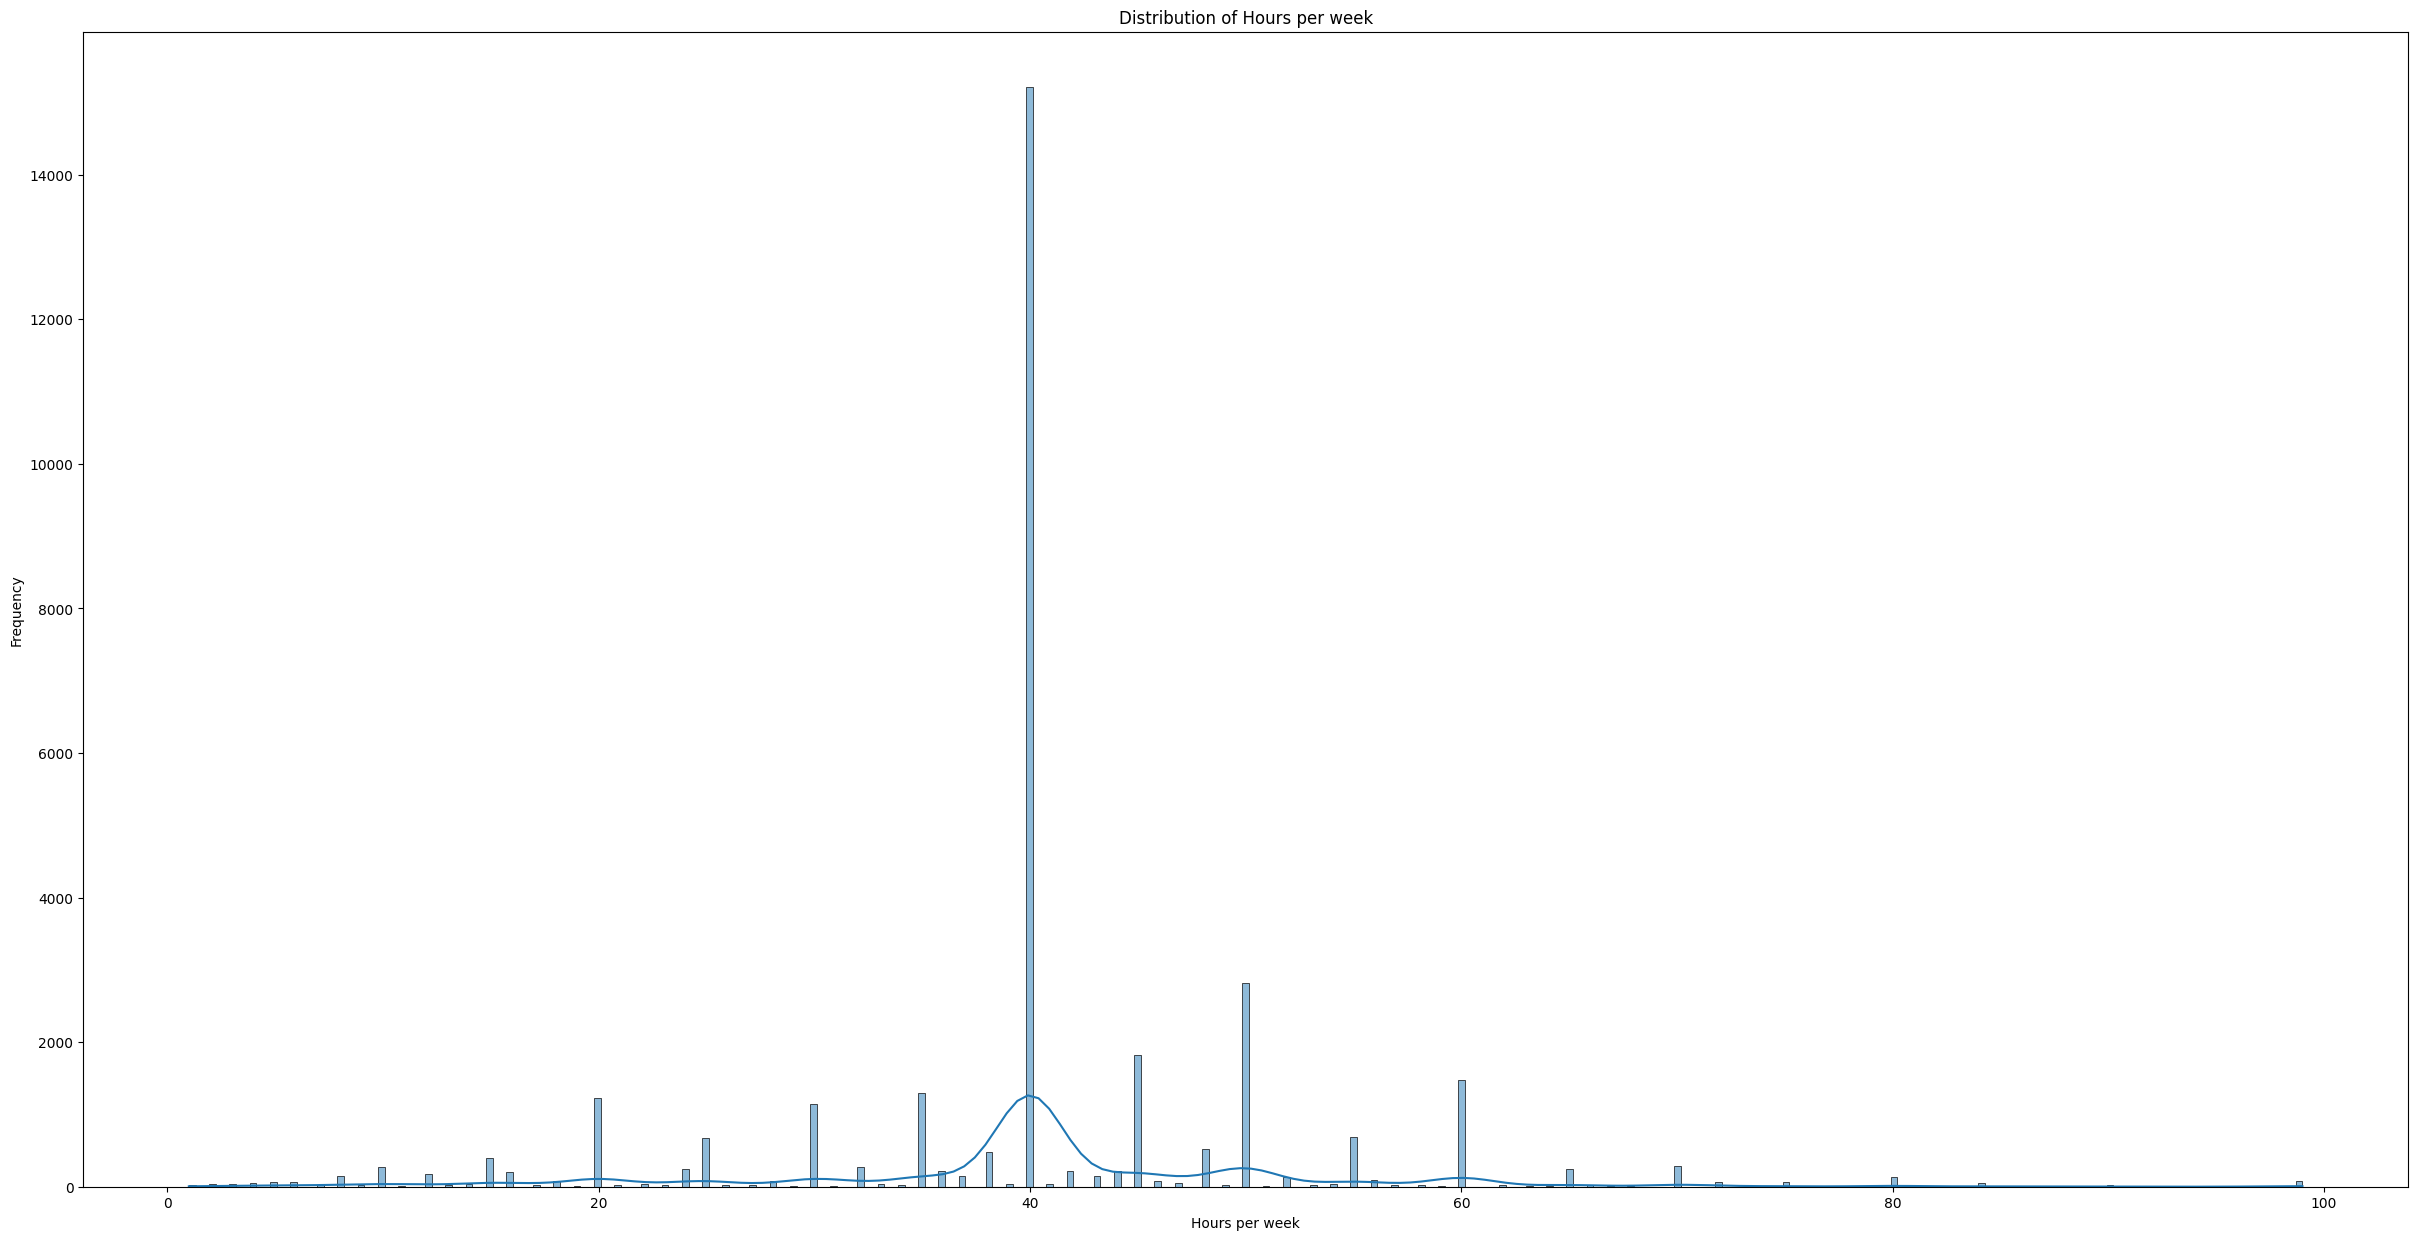

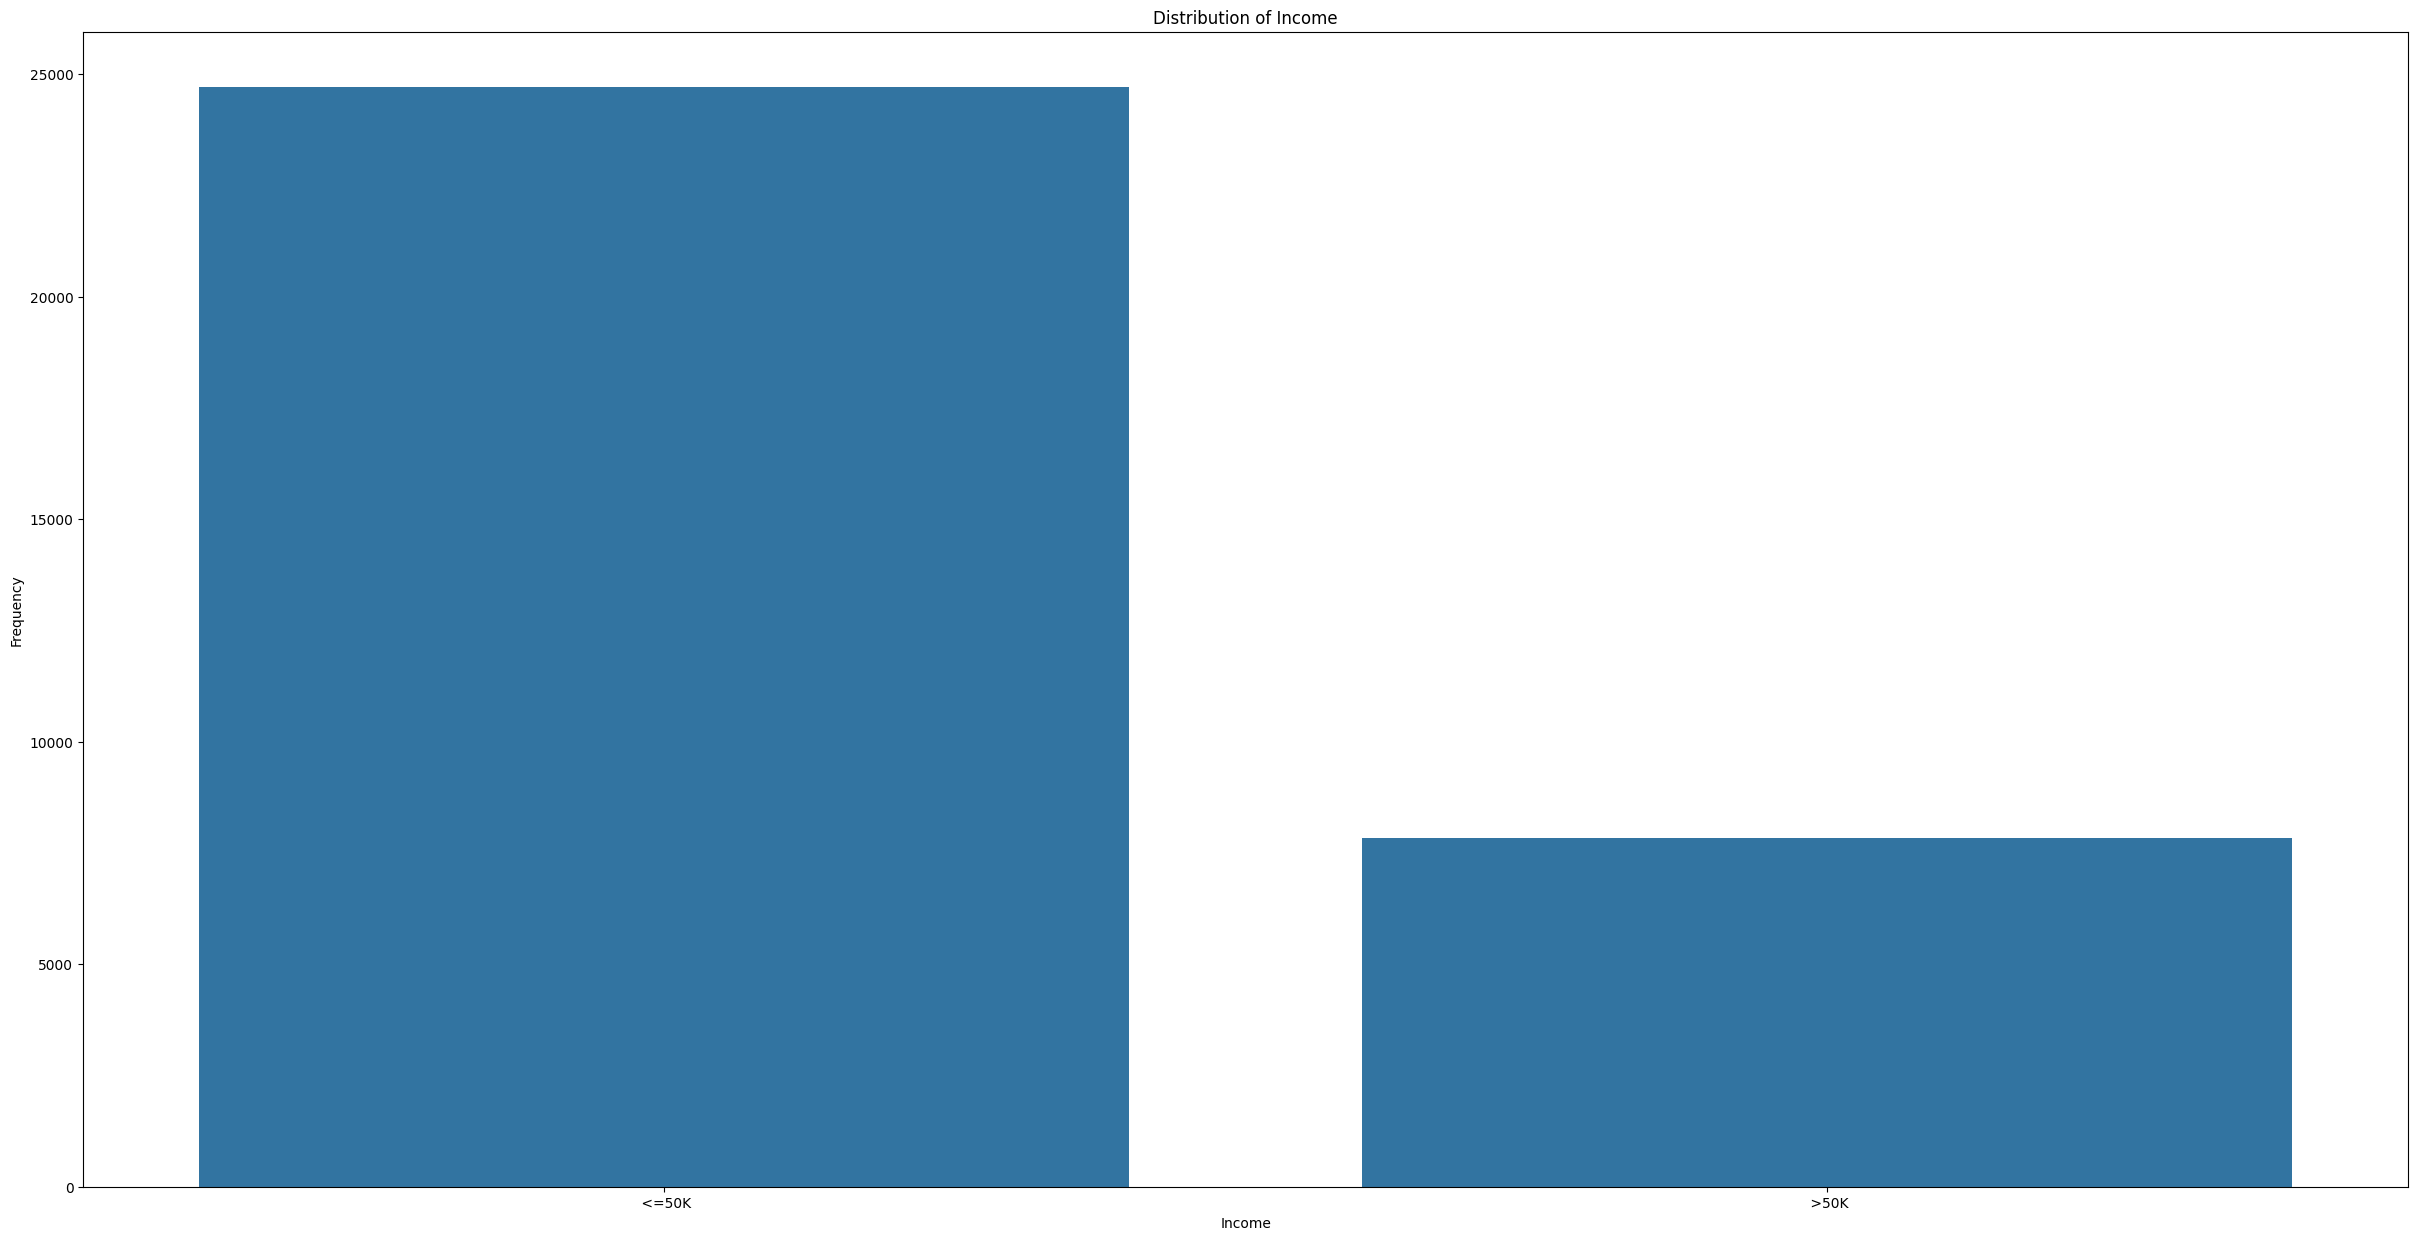

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

for column in df.columns:
    plt.figure(figsize=(30, 15))
    if df[column].dtype == "str":
        sns.countplot(x=column, data=df)
    else:
        sns.histplot(df[column], kde=True)

    column_name = column.replace("-", " ").capitalize()
    plt.title(f"Distribution of {column_name}")
    plt.xlabel(column_name)
    plt.ylabel("Frequency")
    plt.show()

## Model Building


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [8]:
from sklearn.linear_model import LogisticRegression

# Train a Logistic Regression model using scikit-learn
sklearn_model = LogisticRegression(max_iter=2000)
sklearn_model.fit(X_train, y_train)

# Display model coefficients and interpret their significance
coefficients = pd.DataFrame(
    {"Feature": X.columns, "Coefficient": sklearn_model.coef_[0]}
).sort_values(by="Coefficient", ascending=False)
print(coefficients)

                                 Feature  Coefficient
21                   education_Doctorate     2.032289
25                 education_Prof-school     2.007720
28      marital-status_Married-AF-spouse     1.402977
23                     education_Masters     1.372817
29     marital-status_Married-civ-spouse     1.288479
20                   education_Bachelors     0.962392
38            occupation_Exec-managerial     0.814870
47               occupation_Tech-support     0.643834
45            occupation_Protective-serv     0.576588
44             occupation_Prof-specialty     0.534351
3                  workclass_Federal-gov     0.447463
18                  education_Assoc-acdm     0.429339
19                   education_Assoc-voc     0.361599
46                      occupation_Sales     0.311503
7                 workclass_Self-emp-inc     0.157230
26                education_Some-college     0.124699
37               occupation_Craft-repair     0.057260
35               occupation_

In [9]:
class LogisticRegressionGD:
    def __init__(self, lr: float = 0.1, max_iter: int = 2000):
        self.lr = lr
        self.max_iter = max_iter

    def sigmoid(self, z):
        z = np.asarray(z, dtype=np.float64)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)

        self.W = np.zeros(X.shape[1])
        self.bias = 0
        m = len(y)

        for _ in range(self.max_iter):
            z = np.dot(X, self.W) + self.bias
            h = self.sigmoid(z)

            gradient_W = np.dot(X.T, (h - y)) / m
            gradient_bias = np.sum(h - y) / m

            self.W -= self.lr * gradient_W
            self.bias -= self.lr * gradient_bias

    def predict(self, X):
        X = np.asarray(X, dtype=np.float64)

        z = np.dot(X, self.W) + self.bias
        h = self.sigmoid(z)
        return (h >= 0.5).astype(int)


custom_model = LogisticRegressionGD()
custom_model.fit(X_train, y_train)

## Model Evaluation


In [10]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = sklearn_model.predict(X_test)
cf_matrix = confusion_matrix(y_test, y_pred)
cls_report = classification_report(y_test, y_pred)

print("Confusion Matrix:", cf_matrix, "Classification Report:", cls_report, sep="\n")

Confusion Matrix:
[[6894  561]
 [1062 1252]]
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.92      0.89      7455
           1       0.69      0.54      0.61      2314

    accuracy                           0.83      9769
   macro avg       0.78      0.73      0.75      9769
weighted avg       0.82      0.83      0.83      9769



In [11]:
y_pred = custom_model.predict(X_test)
cf_matrix = confusion_matrix(y_test, y_pred)
cls_report = classification_report(y_test, y_pred, zero_division=0)

print("Confusion Matrix:", cf_matrix, "Classification Report:", cls_report, sep="\n")

Confusion Matrix:
[[6121 1334]
 [ 856 1458]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      7455
           1       0.52      0.63      0.57      2314

    accuracy                           0.78      9769
   macro avg       0.70      0.73      0.71      9769
weighted avg       0.79      0.78      0.78      9769



### Discuss potential improvements to the model

Because the dataset is heavily imbalanced, these solutions may improve the model:

- The default 0.5 probability threshold may be inappropriate for imbalanced data. Lowering the threshold could improve recall for the minority class.
- Use `class_weight` parameter in scikit-learn's `LogisticRegression` to penalize misclassification of the minority class.


### Give information about how well the logistic regression model works overall

#### The Imbalance Problem

The Support column shows how many times each class actually happened:

- Class 0: 7,455 samples (about 76% of the data)
- Class 1: 2,314 samples (about 24% of the data)

The model can get a high accuracy just by being good at predicting the majority, which is Class 0, and failing a lot on the minority.

#### Performance

- The model is only 69% accurate when it predicts Class 1, which means 31% of its "positive" forecasts are false positives.
- The 54% recall on 1 means just 54% of real Class 1 cases are predicted successfully by the model. Therefore, this model is biased to Class 1 because of the imbalanced dataset.


## Improvements


In [12]:
sklearn_model = LogisticRegression(max_iter=5000, class_weight={0: 1, 1: 2})
sklearn_model.fit(X_train, y_train)

y_pred = sklearn_model.predict(X_test)
cf_matrix = confusion_matrix(y_test, y_pred)
cls_report = classification_report(y_test, y_pred)

print("Confusion Matrix:", cf_matrix, "Classification Report:", cls_report, sep="\n")

Confusion Matrix:
[[6288 1167]
 [ 632 1682]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.84      0.87      7455
           1       0.59      0.73      0.65      2314

    accuracy                           0.82      9769
   macro avg       0.75      0.79      0.76      9769
weighted avg       0.83      0.82      0.82      9769

